In [1]:
!pip install mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 104.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 96.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import json
import time
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from joblib import Parallel, delayed

import mlflow
import dagshub

from prophet import Prophet

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger("mlflow.pytorch").setLevel(logging.ERROR)
logging.getLogger("mlflow.utils.requirements_utils").setLevel(logging.ERROR)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

dagshub.init(repo_owner='ejoba22', repo_name='walmart-sales-forecasting', mlflow=True)
mlflow.set_experiment("Prophet_Training")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("Prophet_Training"))

BASE = '/kaggle/input/datasets/elenejobava/walmart-features-engineered/'

train_fe = pd.read_parquet(BASE + 'train_features.parquet')
test_fe  = pd.read_parquet(BASE + 'test_features.parquet')

with open(BASE + 'feature_cols.json') as f:
    feature_cols = json.load(f)

train_fe["Date"] = pd.to_datetime(train_fe["Date"])
test_fe["Date"]  = pd.to_datetime(test_fe["Date"])

print("\nTrain:", train_fe.shape, train_fe["Date"].min(), "->", train_fe["Date"].max())
print("Test :", test_fe.shape,  test_fe["Date"].min(),  "->", test_fe["Date"].max())

TRAIN_WEEKS = 143
TEST_HORIZON = 39
CV_FOLD_HORIZON = 13
N_CV_FOLDS = 3

fold_cutoffs = []
for i in range(N_CV_FOLDS):
    val_end = TRAIN_WEEKS - (N_CV_FOLDS - 1 - i) * CV_FOLD_HORIZON
    val_start = val_end - CV_FOLD_HORIZON
    fold_cutoffs.append((val_start, val_end))

print("\nCV fold cutoffs (reused from DLinear for cross-model comparability):")
for i, (vs, ve) in enumerate(fold_cutoffs):
    print(f"  Fold {i}: train < week {vs}, validate on weeks [{vs}, {ve})")

train_pairs_all = set(zip(train_fe.Store, train_fe.Dept))
test_pairs_all  = set(zip(test_fe.Store, test_fe.Dept))
cold_start_pairs = list(test_pairs_all - train_pairs_all)
active_pairs = sorted(train_pairs_all)

print(f"\nActive Store-Dept series: {len(active_pairs)}")
print(f"Cold-start pairs (no train history): {len(cold_start_pairs)}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=52d5a57b-269b-4282-b527-b5e81a9fc77f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=b1d0ab5c064935ebaeb94acff69d779bfa762b2dd3a18831bcebba920be41c49




Accessing as ejoba22

Initialized MLflow to track repo "ejoba22/walmart-sales-forecasting"

Repository ejoba22/walmart-sales-forecasting initialized!

Tracking URI: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow
Active experiment: <Experiment: artifact_location='mlflow-artifacts:/2583975e296448aaa19e8254e09d3430', creation_time=1783782659595, effective_trace_archival_retention=None, experiment_id='5', last_update_time=1783782659595, lifecycle_stage='active', name='Prophet_Training', tags={}, trace_location=None, workspace='default'>

Train: (421570, 57) 2010-02-05 00:00:00 -> 2012-10-26 00:00:00
Test : (115064, 56) 2012-11-02 00:00:00 -> 2013-07-26 00:00:00

CV fold cutoffs (reused from DLinear for cross-model comparability):
  Fold 0: train < week 104, validate on weeks [104, 117)
  Fold 1: train < week 117, validate on weeks [117, 130)
  Fold 2: train < week 130, validate on weeks [130, 143)

Active Store-Dept series: 3331
Cold-start pairs (no train history): 11


## 1. Full Panel Construction

In [3]:
full_date_range = pd.date_range(train_fe["Date"].min(), test_fe["Date"].max(), freq="7D")

calendar_cols = [
    'IsHoliday', 'Year', 'Month', 'Week', 'DayOfYear', 'Quarter', 'Year_norm',
    'Week_sin', 'Week_cos', 'Month_sin', 'Month_cos',
    'weeks_to_SuperBowl', 'near_SuperBowl', 'before_SuperBowl',
    'weeks_to_LaborDay', 'near_LaborDay', 'before_LaborDay',
    'weeks_to_Thanksgiving', 'near_Thanksgiving', 'before_Thanksgiving',
    'weeks_to_Christmas', 'near_Christmas', 'before_Christmas',
    'is_super_bowl', 'is_labor_day', 'is_thanksgiving', 'is_christmas',
    # new — Store-Date level, time-varying:
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'total_markdown', 'markdown_x_holiday', 'any_markdown', 'active_markdown_count',
]

store_covariates = pd.concat([
    train_fe[['Store', 'Date'] + calendar_cols],
    test_fe[['Store', 'Date'] + calendar_cols]
], axis=0).drop_duplicates(subset=['Store', 'Date']).sort_values(['Store', 'Date'])

target_rows = []
for store_i, dept_i in active_pairs:
    obs = train_fe[(train_fe.Store == store_i) & (train_fe.Dept == dept_i)][['Date', 'Weekly_Sales']]
    obs = obs.set_index('Date').reindex(full_date_range)
    obs['Store'] = store_i
    obs['Dept'] = dept_i
    obs['is_active'] = obs['Weekly_Sales'].notna().astype(int)
    obs['Weekly_Sales'] = obs['Weekly_Sales'].fillna(0)
    obs = obs.reset_index().rename(columns={'index': 'Date'})
    target_rows.append(obs)

target_panel = pd.concat(target_rows, axis=0, ignore_index=True)
full_panel = target_panel.merge(store_covariates, on=['Store', 'Date'], how='left')

print("Full panel shape:", full_panel.shape)
print("Nulls after merge:\n", full_panel.isnull().sum()[full_panel.isnull().sum() > 0])
print("\nSample:")
print(full_panel.head())

Full panel shape: (606242, 40)
Nulls after merge:
 Series([], dtype: int64)

Sample:
        Date  Weekly_Sales  Store  Dept  is_active  IsHoliday  Year  Month  \
0 2010-02-05      24924.50      1     1          1          0  2010      2   
1 2010-02-12      46039.49      1     1          1          1  2010      2   
2 2010-02-19      41595.55      1     1          1          0  2010      2   
3 2010-02-26      19403.54      1     1          1          0  2010      2   
4 2010-03-05      21827.90      1     1          1          0  2010      3   

   Week  DayOfYear  ...  is_thanksgiving  is_christmas  Temperature  \
0     5         36  ...                0             0        42.31   
1     6         43  ...                0             0        38.51   
2     7         50  ...                0             0        39.93   
3     8         57  ...                0             0        46.63   
4     9         64  ...                0             0        46.50   

   Fuel_Price      

## 2. Small-Sample Validation (150 series)

In [4]:
def build_prophet_frame(panel, store_i, dept_i, cutoff_week):
    series = panel[(panel.Store == store_i) & (panel.Dept == dept_i)].sort_values('Date').reset_index(drop=True)
    history = series.iloc[:cutoff_week]
    df = history[['Date', 'Weekly_Sales', 'IsHoliday']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    return df, series

def fit_predict_one_series(store_i, dept_i, panel, cutoff_week, horizon):
    train_df, full_series = build_prophet_frame(panel, store_i, dept_i, cutoff_week)
    if len(train_df) < 10:
        return None

    future_slice = full_series.iloc[cutoff_week:cutoff_week + horizon]
    if len(future_slice) == 0:
        return None

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
    )
    m.add_regressor('IsHoliday')

    try:
        m.fit(train_df[['ds', 'y', 'IsHoliday']])
    except Exception as e:
        return {'store': store_i, 'dept': dept_i, 'error': str(e)}

    future = future_slice[['Date', 'IsHoliday']].rename(columns={'Date': 'ds'})
    forecast = m.predict(future)

    actual = future_slice['Weekly_Sales'].values
    pred = np.clip(forecast['yhat'].values, 0, None)
    weight = np.where(future_slice['IsHoliday'].values.astype(bool), 5.0, 1.0)
    wmae = np.sum(weight * np.abs(pred - actual)) / np.sum(weight)

    return {'store': store_i, 'dept': dept_i, 'wmae': wmae, 'n_train': len(train_df), 'n_test': len(future_slice)}


sample_pairs = active_pairs[:150]
val_cutoff = fold_cutoffs[0][0]

start_time = time.time()
sample_results = [fit_predict_one_series(s, d, full_panel, val_cutoff, CV_FOLD_HORIZON) for s, d in sample_pairs]
elapsed = time.time() - start_time

sample_results_clean = [r for r in sample_results if r is not None and 'wmae' in r]
sample_errors = [r for r in sample_results if r is not None and 'error' in r]

print(f"Sample of {len(sample_pairs)} series fit in {elapsed:.1f}s ({elapsed/len(sample_pairs):.3f}s/series)")
print(f"Successful fits: {len(sample_results_clean)}, Errors: {len(sample_errors)}")
if sample_errors:
    print("Example error:", sample_errors[0])

sample_df = pd.DataFrame(sample_results_clean)
print("\nSample WMAE stats:")
print(sample_df['wmae'].describe())

estimated_full_serial = elapsed / len(sample_pairs) * len(active_pairs)
print(f"\nEstimated time for full {len(active_pairs)} series (serial): {estimated_full_serial/60:.1f} minutes")

08:11:24 - cmdstanpy - INFO - Chain [1] start processing
08:11:24 - cmdstanpy - INFO - Chain [1] done processing
08:11:24 - cmdstanpy - INFO - Chain [1] start processing
08:11:24 - cmdstanpy - INFO - Chain [1] done processing
08:11:24 - cmdstanpy - INFO - Chain [1] start processing
08:11:24 - cmdstanpy - INFO - Chain [1] done processing
08:11:24 - cmdstanpy - INFO - Chain [1] start processing
08:11:24 - cmdstanpy - INFO - Chain [1] done processing
08:11:24 - cmdstanpy - INFO - Chain [1] start processing
08:11:24 - cmdstanpy - INFO - Chain [1] done processing
08:11:24 - cmdstanpy - INFO - Chain [1] start processing
08:11:24 - cmdstanpy - INFO - Chain [1] done processing
08:11:24 - cmdstanpy - INFO - Chain [1] start processing
08:11:24 - cmdstanpy - INFO - Chain [1] done processing
08:11:25 - cmdstanpy - INFO - Chain [1] start processing
08:11:25 - cmdstanpy - INFO - Chain [1] done processing
08:11:25 - cmdstanpy - INFO - Chain [1] start processing
08:11:25 - cmdstanpy - INFO - Chain [1]

Sample of 150 series fit in 12.9s (0.086s/series)
Successful fits: 150, Errors: 0

Sample WMAE stats:
count      150.000000
mean      2360.820959
std       2426.149263
min          0.000000
25%        581.456879
50%       1405.879580
75%       3556.663678
max      10626.101869
Name: wmae, dtype: float64

Estimated time for full 3331 series (serial): 4.8 minutes


In [5]:
import io
import contextlib

@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = os.dup(1), os.dup(2)
        os.dup2(devnull.fileno(), 1)
        os.dup2(devnull.fileno(), 2)
        try:
            yield
        finally:
            os.dup2(old_stdout, 1)
            os.dup2(old_stderr, 2)
            os.close(old_stdout)
            os.close(old_stderr)

In [6]:
import logging

cmdstanpy_logger = logging.getLogger('cmdstanpy')
cmdstanpy_logger.handlers = []
cmdstanpy_logger.setLevel(logging.CRITICAL)
cmdstanpy_logger.propagate = False

In [7]:
import io
import contextlib

@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = os.dup(1), os.dup(2)
        os.dup2(devnull.fileno(), 1)
        os.dup2(devnull.fileno(), 2)
        try:
            yield
        finally:
            os.dup2(old_stdout, 1)
            os.dup2(old_stderr, 2)
            os.close(old_stdout)
            os.close(old_stderr)


def fit_predict_one_series_detailed(store_i, dept_i, panel, cutoff_week, horizon):
    train_df, full_series = build_prophet_frame(panel, store_i, dept_i, cutoff_week)
    if len(train_df) < 10:
        return None

    future_slice = full_series.iloc[cutoff_week:cutoff_week + horizon]
    if len(future_slice) == 0:
        return None

    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
        seasonality_mode='multiplicative', changepoint_prior_scale=0.05,
    )
    m.add_regressor('IsHoliday')

    try:
        with suppress_stdout_stderr():
            m.fit(train_df[['ds', 'y', 'IsHoliday']])
    except Exception as e:
        return {'store': store_i, 'dept': dept_i, 'error': str(e)}

    future = future_slice[['Date', 'IsHoliday']].rename(columns={'Date': 'ds'})
    with suppress_stdout_stderr():
        forecast = m.predict(future)

    actual = future_slice['Weekly_Sales'].values
    pred = np.clip(forecast['yhat'].values, 0, None)
    is_holiday = future_slice['IsHoliday'].values.astype(bool)
    weight = np.where(is_holiday, 5.0, 1.0)
    abs_err = np.abs(pred - actual)

    return {
        'store': store_i, 'dept': dept_i,
        'sum_weighted_err': float(np.sum(weight * abs_err)),
        'sum_weight': float(np.sum(weight)),
        'n_train': len(train_df), 'n_test': len(future_slice),
        'holiday_abs_err_sum': float(abs_err[is_holiday].sum()) if is_holiday.any() else 0.0,
        'holiday_n': int(is_holiday.sum()),
        'nonholiday_abs_err_sum': float(abs_err[~is_holiday].sum()) if (~is_holiday).any() else 0.0,
        'nonholiday_n': int((~is_holiday).sum()),
    }


fold_prophet_results = []

for fold_i, (val_start, val_end) in enumerate(fold_cutoffs):
    records = []
    errors = []
    start_time = time.time()

    for store_i, dept_i in active_pairs:
        r = fit_predict_one_series_detailed(store_i, dept_i, full_panel, val_start, CV_FOLD_HORIZON)
        if r is None:
            continue
        if 'error' in r:
            errors.append(r)
        else:
            records.append(r)

    elapsed = time.time() - start_time
    fold_df = pd.DataFrame(records)

    global_wmae = fold_df['sum_weighted_err'].sum() / fold_df['sum_weight'].sum()
    holiday_mae = fold_df['holiday_abs_err_sum'].sum() / fold_df['holiday_n'].sum() if fold_df['holiday_n'].sum() > 0 else np.nan
    nonholiday_mae = fold_df['nonholiday_abs_err_sum'].sum() / fold_df['nonholiday_n'].sum()

    print(f"Fold {fold_i}: {len(records)} series fit, {len(errors)} errors, {elapsed/60:.1f} min")
    print(f"  Global WMAE: {global_wmae:.2f} | Holiday MAE: {holiday_mae:.2f} | Non-holiday MAE: {nonholiday_mae:.2f}")

    with mlflow.start_run(run_name=f"Prophet_Fold{fold_i}_Baseline"):
        mlflow.set_tags({"model_type": "Prophet", "fold": str(fold_i), "run_type": "baseline"})
        mlflow.log_params({
            "yearly_seasonality": True, "weekly_seasonality": False, "daily_seasonality": False,
            "seasonality_mode": "multiplicative", "changepoint_prior_scale": 0.05,
            "regressors": "IsHoliday", "fold": fold_i, "horizon": CV_FOLD_HORIZON,
            "n_series_fit": len(records), "n_series_error": len(errors),
        })
        mlflow.log_metric("global_wmae", global_wmae)
        mlflow.log_metric("holiday_mae", holiday_mae)
        mlflow.log_metric("nonholiday_mae", nonholiday_mae)
        mlflow.log_metric("fit_time_minutes", elapsed / 60)
        mlflow.log_metric("mean_per_series_wmae", (fold_df['sum_weighted_err'] / fold_df['sum_weight']).mean())
        mlflow.log_metric("std_per_series_wmae", (fold_df['sum_weighted_err'] / fold_df['sum_weight']).std())

        fold_df.to_csv(f'prophet_fold{fold_i}_per_series.csv', index=False)
        mlflow.log_artifact(f'prophet_fold{fold_i}_per_series.csv')

        if errors:
            pd.DataFrame(errors).to_csv(f'prophet_fold{fold_i}_errors.csv', index=False)
            mlflow.log_artifact(f'prophet_fold{fold_i}_errors.csv')

    fold_prophet_results.append({
        "fold": fold_i, "global_wmae": global_wmae, "holiday_mae": holiday_mae,
        "nonholiday_mae": nonholiday_mae, "n_series": len(records), "fit_minutes": elapsed / 60
    })

prophet_cv_summary = pd.DataFrame(fold_prophet_results)
print("\nProphet CV Summary:")
print(prophet_cv_summary)
print("\nMean Global WMAE across folds:", prophet_cv_summary["global_wmae"].mean())

Fold 0: 3331 series fit, 0 errors, 4.4 min
  Global WMAE: 1567.07 | Holiday MAE: 1669.31 | Non-holiday MAE: 1524.46
🏃 View run Prophet_Fold0_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5/runs/beda52ab8a314de480695611e8598b7b
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5
Fold 1: 3331 series fit, 0 errors, 4.1 min
  Global WMAE: 1322.29 | Holiday MAE: nan | Non-holiday MAE: 1322.29
🏃 View run Prophet_Fold1_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5/runs/95b3cd0facf94f5681a585987a47d506
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5
Fold 2: 3331 series fit, 0 errors, 4.2 min
  Global WMAE: 1445.84 | Holiday MAE: 1704.61 | Non-holiday MAE: 1338.02
🏃 View run Prophet_Fold2_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5/runs/d3fd4d134702430cbb903c0c88991c47

## 4. Intentional Overfit / Underfit Demos

In [8]:
# def fit_with_timeout(store_i, dept_i, panel, cutoff_week, horizon, cfg, timeout_sec=10):
#     signal.signal(signal.SIGALRM, timeout_handler)
#     signal.alarm(timeout_sec)
#     try:
#         result = fit_predict_configurable(store_i, dept_i, panel, cutoff_week, horizon, **cfg)
#         signal.alarm(0)
#         return result
#     except TimeoutException:
#         signal.alarm(0)
#         return None
#     except Exception:
#         signal.alarm(0)
#         return None


# configs = {
#     "overfit": {"changepoint_prior_scale": 1.0, "yearly_seasonality": True, "train_history_weeks": 15},
#     "underfit": {"changepoint_prior_scale": 0.001, "yearly_seasonality": False, "train_history_weeks": None},
# }

# regime_results = {"baseline": {"in_sample": 2010.60, "out_sample": 2503.32}}

# for regime_name, cfg in configs.items():
#     recs = []
#     timeouts = 0
#     start_time = time.time()

#     for s, d in demo_pairs:
#         r = fit_with_timeout(s, d, full_panel, val_cutoff, CV_FOLD_HORIZON, cfg, timeout_sec=10)
#         if r is None:
#             timeouts += 1
#         else:
#             recs.append(r)

#     elapsed = time.time() - start_time
#     regime_df = pd.DataFrame(recs)
#     mean_in = regime_df['in_sample_mae'].mean()
#     mean_out = regime_df['out_sample_wmae'].mean()

#     print(f"{regime_name}: {len(recs)} fit, {timeouts} skipped (timeout/error), {elapsed:.1f}s")
#     print(f"  in-sample MAE={mean_in:.2f} | out-of-sample WMAE={mean_out:.2f} | gap={mean_out - mean_in:.2f}")

#     with mlflow.start_run(run_name=f"Prophet_{regime_name.capitalize()}_Demo"):
#         mlflow.set_tags({"model_type": "Prophet", "run_type": f"intentional_{regime_name}"})
#         mlflow.log_params({**cfg, "n_series_attempted": len(demo_pairs), "n_series_fit": len(recs), "n_timeouts": timeouts})
#         mlflow.log_metric("mean_in_sample_mae", mean_in)
#         mlflow.log_metric("mean_out_sample_wmae", mean_out)
#         mlflow.log_metric("gap", mean_out - mean_in)

#     regime_results[regime_name] = {"in_sample": mean_in, "out_sample": mean_out}

# print("\nRegime comparison:")
# print(pd.DataFrame(regime_results).T)

## 5. Log-Transform Ablation

In [9]:
def fit_predict_log(store_i, dept_i, panel, cutoff_week, horizon):
    series = panel[(panel.Store == store_i) & (panel.Dept == dept_i)].sort_values('Date').reset_index(drop=True)
    history = series.iloc[:cutoff_week]
    if len(history) < 10:
        return None

    future_slice = series.iloc[cutoff_week:cutoff_week + horizon]
    if len(future_slice) == 0:
        return None

    train_df = history[['Date', 'Weekly_Sales', 'IsHoliday']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    train_df['y'] = np.log1p(train_df['y'].clip(lower=0))

    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
        seasonality_mode='additive', changepoint_prior_scale=0.05,
    )
    m.add_regressor('IsHoliday')

    try:
        with suppress_stdout_stderr():
            m.fit(train_df[['ds', 'y', 'IsHoliday']])
    except Exception as e:
        return {'store': store_i, 'dept': dept_i, 'error': str(e)}

    future = future_slice[['Date', 'IsHoliday']].rename(columns={'Date': 'ds'})
    with suppress_stdout_stderr():
        forecast = m.predict(future)

    pred_log = forecast['yhat'].values
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    actual = future_slice['Weekly_Sales'].values
    weight = np.where(future_slice['IsHoliday'].values.astype(bool), 5.0, 1.0)
    abs_err = np.abs(pred - actual)

    return {
        'store': store_i, 'dept': dept_i,
        'sum_weighted_err': float(np.sum(weight * abs_err)),
        'sum_weight': float(np.sum(weight)),
    }


log_records = []
log_errors = []
start_time = time.time()

for store_i, dept_i in active_pairs:
    r = fit_predict_log(store_i, dept_i, full_panel, fold_cutoffs[0][0], CV_FOLD_HORIZON)
    if r is None:
        continue
    if 'error' in r:
        log_errors.append(r)
    else:
        log_records.append(r)

elapsed = time.time() - start_time
log_df = pd.DataFrame(log_records)
log_global_wmae = log_df['sum_weighted_err'].sum() / log_df['sum_weight'].sum()

print(f"Log-transform: {len(log_records)} series fit, {len(log_errors)} errors, {elapsed/60:.1f} min")
print(f"Global WMAE (log-transform): {log_global_wmae:.2f}")
print(f"Global WMAE (baseline, no transform): {prophet_cv_summary.loc[0, 'global_wmae']:.2f}")

with mlflow.start_run(run_name="Prophet_LogTransform_Ablation"):
    mlflow.set_tags({"model_type": "Prophet", "run_type": "ablation", "transform": "log1p"})
    mlflow.log_params({
        "changepoint_prior_scale": 0.05, "seasonality_mode": "additive",
        "target_transform": "log1p", "fold": 0, "n_series_fit": len(log_records),
    })
    mlflow.log_metric("global_wmae", log_global_wmae)
    mlflow.log_metric("fit_time_minutes", elapsed / 60)
    log_df.to_csv('prophet_log_transform_per_series.csv', index=False)
    mlflow.log_artifact('prophet_log_transform_per_series.csv')

Log-transform: 3331 series fit, 0 errors, 4.2 min
Global WMAE (log-transform): 1747.40
Global WMAE (baseline, no transform): 1567.07
🏃 View run Prophet_LogTransform_Ablation at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5/runs/563d1cf2bde940cd8737571ba06713d3
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5


In [10]:
neg_sales = train_fe[train_fe['Weekly_Sales'] < 0]
print("Negative Weekly_Sales rows:", len(neg_sales), "out of", len(train_fe))
print("Most negative value:", train_fe['Weekly_Sales'].min())
print(neg_sales[['Store', 'Dept', 'Date', 'Weekly_Sales']].describe())

Negative Weekly_Sales rows: 1285 out of 421570
Most negative value: -4988.94
             Store         Dept                           Date  Weekly_Sales
count  1285.000000  1285.000000                           1285   1285.000000
mean     23.858366    49.999222  2011-07-03 19:19:50.661478656    -68.608218
min       1.000000     5.000000            2010-02-05 00:00:00  -4988.940000
25%      15.000000    31.000000            2010-11-12 00:00:00    -41.000000
50%      22.000000    47.000000            2011-07-01 00:00:00    -13.200000
75%      35.000000    59.000000            2012-03-16 00:00:00     -4.940000
max      45.000000    99.000000            2012-10-26 00:00:00     -0.020000
std      12.033126    24.394330                            NaN    231.664245


## 6. Final Model (143-week train / 39-week horizon)

In [11]:
def fit_predict_final(store_i, dept_i, panel, cutoff_week, horizon):
    series = panel[(panel.Store == store_i) & (panel.Dept == dept_i)].sort_values('Date').reset_index(drop=True)
    history = series.iloc[:cutoff_week]
    if len(history) < 10:
        return None

    future_slice = series.iloc[cutoff_week:cutoff_week + horizon]
    if len(future_slice) == 0:
        return None

    train_df = history[['Date', 'Weekly_Sales', 'IsHoliday']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    train_df['y'] = train_df['y'].clip(lower=0)

    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
        seasonality_mode='multiplicative', changepoint_prior_scale=0.05,
    )
    m.add_regressor('IsHoliday')

    try:
        with suppress_stdout_stderr():
            m.fit(train_df[['ds', 'y', 'IsHoliday']])
    except Exception as e:
        return {'store': store_i, 'dept': dept_i, 'error': str(e)}

    future = future_slice[['Date', 'IsHoliday']].rename(columns={'Date': 'ds'})
    with suppress_stdout_stderr():
        forecast = m.predict(future)

    pred = np.clip(forecast['yhat'].values, 0, None)
    actual = future_slice['Weekly_Sales'].values
    is_holiday = future_slice['IsHoliday'].values.astype(bool)
    weight = np.where(is_holiday, 5.0, 1.0)
    abs_err = np.abs(pred - actual)

    return {
        'store': store_i, 'dept': dept_i,
        'pred': pred.tolist(), 'actual': actual.tolist(), 'dates': future_slice['Date'].dt.strftime('%Y-%m-%d').tolist(),
        'sum_weighted_err': float(np.sum(weight * abs_err)),
        'sum_weight': float(np.sum(weight)),
        'holiday_abs_err_sum': float(abs_err[is_holiday].sum()) if is_holiday.any() else 0.0,
        'holiday_n': int(is_holiday.sum()),
        'nonholiday_abs_err_sum': float(abs_err[~is_holiday].sum()) if (~is_holiday).any() else 0.0,
        'nonholiday_n': int((~is_holiday).sum()),
    }


final_cutoff = TRAIN_WEEKS - TEST_HORIZON
final_records = []
final_errors = []
start_time = time.time()

for store_i, dept_i in active_pairs:
    r = fit_predict_final(store_i, dept_i, full_panel, final_cutoff, TEST_HORIZON)
    if r is None:
        continue
    if 'error' in r:
        final_errors.append(r)
    else:
        final_records.append(r)

elapsed = time.time() - start_time
final_prophet_df = pd.DataFrame(final_records)

final_global_wmae = final_prophet_df['sum_weighted_err'].sum() / final_prophet_df['sum_weight'].sum()
final_holiday_mae = final_prophet_df['holiday_abs_err_sum'].sum() / final_prophet_df['holiday_n'].sum()
final_nonholiday_mae = final_prophet_df['nonholiday_abs_err_sum'].sum() / final_prophet_df['nonholiday_n'].sum()

print(f"Final model: {len(final_records)} series fit, {len(final_errors)} errors, {elapsed/60:.1f} min")
print(f"Global WMAE: {final_global_wmae:.2f}")
print(f"Holiday MAE: {final_holiday_mae:.2f} | Non-holiday MAE: {final_nonholiday_mae:.2f}")

with mlflow.start_run(run_name="Prophet_Final_Model"):
    mlflow.set_tags({"model_type": "Prophet", "run_type": "final"})
    mlflow.log_params({
        "changepoint_prior_scale": 0.05, "seasonality_mode": "multiplicative",
        "regressors": "IsHoliday", "horizon": TEST_HORIZON, "clip_negative_targets": True,
        "n_series_fit": len(final_records), "n_series_error": len(final_errors),
    })
    mlflow.log_metric("global_wmae", final_global_wmae)
    mlflow.log_metric("holiday_mae", final_holiday_mae)
    mlflow.log_metric("nonholiday_mae", final_nonholiday_mae)
    mlflow.log_metric("fit_time_minutes", elapsed / 60)

    final_prophet_df[['store', 'dept', 'sum_weighted_err', 'sum_weight']].to_csv('prophet_final_per_series.csv', index=False)
    mlflow.log_artifact('prophet_final_per_series.csv')

Final model: 3331 series fit, 0 errors, 4.4 min
Global WMAE: 1578.21
Holiday MAE: 1808.12 | Non-holiday MAE: 1516.08
🏃 View run Prophet_Final_Model at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5/runs/3ee16ff624a44a019a24d23f70368082
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5


## 7. Diagnostics Predictions, Residuals, Error Breakdown

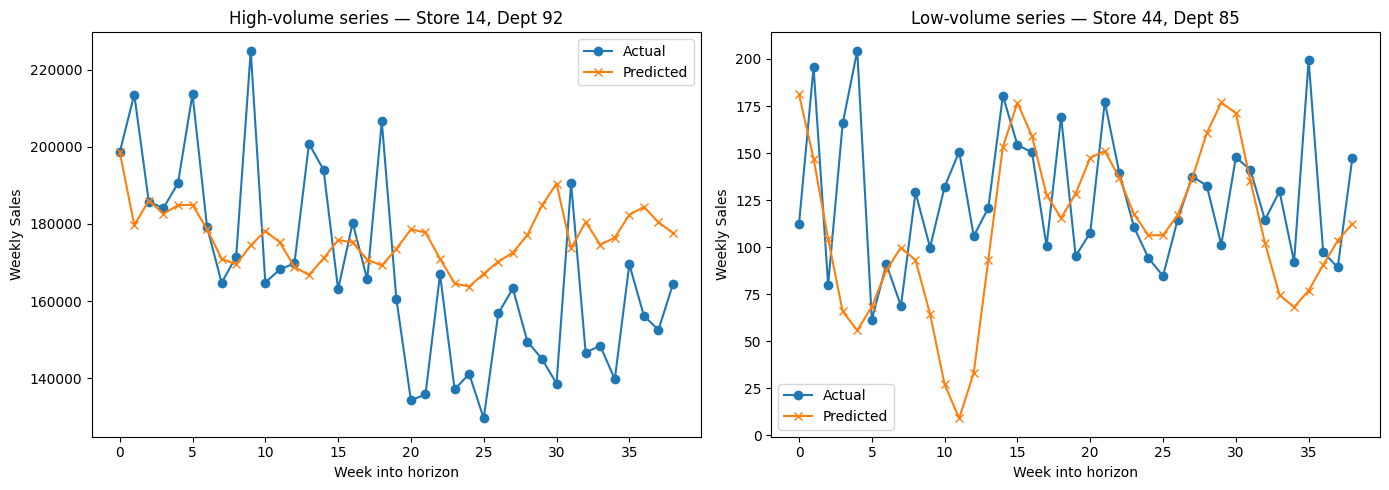

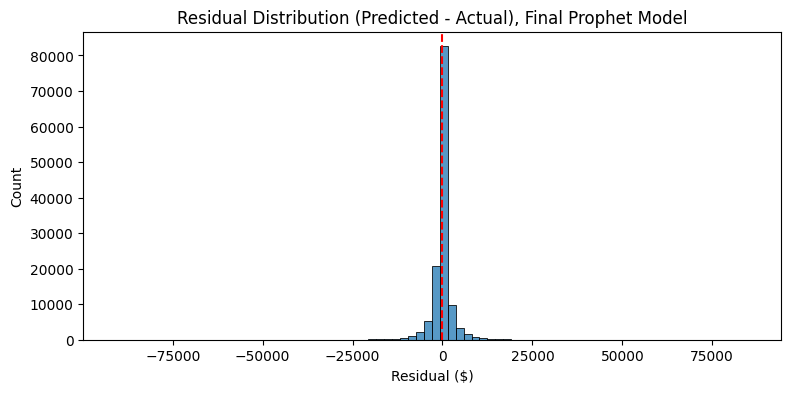

WMAE by store Type:
   Type_enc         WMAE  n_series
0         0   745.659764       374
1         1  1386.012442      1286
2         2  1912.474092      1671


In [12]:
store_dept_avg = full_panel.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
large_pair = store_dept_avg.idxmax()
small_candidates = store_dept_avg[store_dept_avg > 100].sort_values()
small_pair = small_candidates.index[0]

def plot_prophet_series(target_store, target_dept, records_df, ax):
    row = records_df[(records_df.store == target_store) & (records_df.dept == target_dept)]
    if len(row) == 0:
        ax.set_title(f"Store {target_store} Dept {target_dept} — not found")
        return
    row = row.iloc[0]
    ax.plot(row['actual'], label="Actual", marker='o')
    ax.plot(row['pred'], label="Predicted", marker='x')
    ax.set_title(f"Store {target_store}, Dept {target_dept}")
    ax.set_xlabel("Week into horizon")
    ax.set_ylabel("Weekly Sales")
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_prophet_series(large_pair[0], large_pair[1], final_prophet_df, axes[0])
axes[0].set_title("High-volume series — " + axes[0].get_title())
plot_prophet_series(small_pair[0], small_pair[1], final_prophet_df, axes[1])
axes[1].set_title("Low-volume series — " + axes[1].get_title())
plt.tight_layout()
plt.show()

all_actual = np.concatenate([np.array(r) for r in final_prophet_df['actual']])
all_pred = np.concatenate([np.array(r) for r in final_prophet_df['pred']])
residuals = all_pred - all_actual

plt.figure(figsize=(9, 4))
sns.histplot(residuals, bins=80)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution (Predicted - Actual), Final Prophet Model")
plt.xlabel("Residual ($)")
plt.show()

store_type_map = full_panel.drop_duplicates('Store')[['Store']].copy()
store_type_map = train_fe.drop_duplicates('Store')[['Store', 'Type_enc']].set_index('Store')['Type_enc']

type_errors = []
for t in sorted(store_type_map.unique()):
    stores_of_type = set(store_type_map[store_type_map == t].index)
    mask = final_prophet_df['store'].isin(stores_of_type)
    subset = final_prophet_df[mask]
    if len(subset) == 0:
        continue
    err = subset['sum_weighted_err'].sum() / subset['sum_weight'].sum()
    type_errors.append({"Type_enc": t, "WMAE": err, "n_series": mask.sum()})

print("WMAE by store Type:")
print(pd.DataFrame(type_errors))

## 8. Pipeline Wrapper + Model Registry

In [13]:
import mlflow.pyfunc

dept_avg_fallback = train_fe.groupby('Dept')['Weekly_Sales'].mean()

class ProphetPipeline(mlflow.pyfunc.PythonModel):
    def __init__(self, full_panel, active_pairs, cold_start_pairs, dept_avg_fallback,
                 changepoint_prior_scale=0.05, seasonality_mode='multiplicative'):
        self.full_panel = full_panel
        self.active_pairs = set(active_pairs)
        self.cold_start_pairs = set(cold_start_pairs)
        self.dept_avg_fallback = dept_avg_fallback
        self.changepoint_prior_scale = changepoint_prior_scale
        self.seasonality_mode = seasonality_mode

    def predict(self, context, model_input):
        test_df = model_input.copy()
        test_df["Date"] = pd.to_datetime(test_df["Date"])
        predictions = []

        for (store_i, dept_i), group in test_df.groupby(['Store', 'Dept']):
            group = group.sort_values('Date')

            if (store_i, dept_i) in self.cold_start_pairs or (store_i, dept_i) not in self.active_pairs:
                fallback_val = self.dept_avg_fallback.get(dept_i, self.dept_avg_fallback.mean())
                for _, row in group.iterrows():
                    predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': row['Date'], 'Weekly_Sales_Pred': fallback_val})
                continue

            history = self.full_panel[(self.full_panel.Store == store_i) & (self.full_panel.Dept == dept_i)]
            history = history[history['Date'] < group['Date'].min()].sort_values('Date')

            train_df = history[['Date', 'Weekly_Sales', 'IsHoliday']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
            train_df['y'] = train_df['y'].clip(lower=0)

            m = Prophet(
                yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                seasonality_mode=self.seasonality_mode, changepoint_prior_scale=self.changepoint_prior_scale,
            )
            m.add_regressor('IsHoliday')
            m.fit(train_df[['ds', 'y', 'IsHoliday']])

            future = group[['Date', 'IsHoliday']].rename(columns={'Date': 'ds'})
            forecast = m.predict(future)
            pred = np.clip(forecast['yhat'].values, 0, None)

            for step, (_, row) in enumerate(group.iterrows()):
                predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': row['Date'], 'Weekly_Sales_Pred': pred[step]})

        return pd.DataFrame(predictions)


prophet_pipeline = ProphetPipeline(full_panel, active_pairs, cold_start_pairs, dept_avg_fallback)

with mlflow.start_run(run_name="Prophet_Final_Pipeline"):
    mlflow.set_tags({"model_type": "Prophet", "run_type": "final_pipeline"})
    mlflow.log_params({
        "changepoint_prior_scale": 0.05, "seasonality_mode": "multiplicative",
        "regressors": "IsHoliday", "clip_negative_targets": True, "n_series": len(active_pairs),
    })
    mlflow.log_metric("global_wmae", final_global_wmae)
    mlflow.log_metric("holiday_mae", final_holiday_mae)
    mlflow.log_metric("nonholiday_mae", final_nonholiday_mae)

    summary_rows = [
        {"run": "Baseline CV (mean, 3 folds)", "wmae": prophet_cv_summary["global_wmae"].mean(), "notes": f"std={prophet_cv_summary['global_wmae'].std():.1f}"},
        {"run": "Intentional Overfit", "wmae": 214863.36, "notes": "15wk history, changepoint=1.0, gap=214620"},
        {"run": "Intentional Underfit", "wmae": 4236.77, "notes": "changepoint=0.001, no yearly seasonality"},
        {"run": "Log-transform Ablation", "wmae": 1747.40, "notes": "worse than baseline (1567.07)"},
        {"run": "Final Model (39wk horizon)", "wmae": final_global_wmae, "notes": "production model"},
    ]
    summary_df_prophet = pd.DataFrame(summary_rows)
    print(summary_df_prophet.to_string(index=False))

    mlflow.log_table(summary_df_prophet, artifact_file="prophet_summary.json")

    example_input = test_fe[['Store', 'Dept', 'Date', 'IsHoliday']].head(5)
    mlflow.pyfunc.log_model(
        python_model=prophet_pipeline,
        name="model",
        input_example=example_input,
    )

print("\nProphet pipeline logged (not registered — will register only the best architecture overall once all models are compared)")

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


                        run          wmae                                     notes
Baseline CV (mean, 3 folds)   1445.066726                                 std=122.4
        Intentional Overfit 214863.360000 15wk history, changepoint=1.0, gap=214620
       Intentional Underfit   4236.770000  changepoint=0.001, no yearly seasonality
     Log-transform Ablation   1747.400000             worse than baseline (1567.07)
 Final Model (39wk horizon)   1578.214639                          production model


2026/07/21 08:33:10 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/21 08:33:10 INFO mlflow.pyfunc: Inferring model signature from input example
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64)

🏃 View run Prophet_Final_Pipeline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5/runs/8d2a2d3aafa24ef4b8b92c3ccb8461db
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/5

Prophet pipeline logged (not registered — will register only the best architecture overall once all models are compared)


In [14]:
# Re-declares ProphetPipeline so this section works even if Cell 19 hasn't been run yet.
# (If Cell 19 already ran, this just overwrites it with an identical class.)

dept_avg_fallback = train_fe.groupby('Dept')['Weekly_Sales'].mean()

class ProphetPipelineSubmission:
    def __init__(self, full_panel, active_pairs, cold_start_pairs, dept_avg_fallback,
                 changepoint_prior_scale=0.05, seasonality_mode='multiplicative'):
        self.full_panel = full_panel
        self.active_pairs = set(active_pairs)
        self.cold_start_pairs = set(cold_start_pairs)
        self.dept_avg_fallback = dept_avg_fallback
        self.changepoint_prior_scale = changepoint_prior_scale
        self.seasonality_mode = seasonality_mode

    def predict(self, test_df):
        test_df = test_df.copy()
        test_df['Date'] = pd.to_datetime(test_df['Date'])
        predictions = []

        pairs = list(test_df.groupby(['Store', 'Dept']))
        for idx, ((store_i, dept_i), group) in enumerate(pairs):
            group = group.sort_values('Date')

            if (store_i, dept_i) in self.cold_start_pairs or (store_i, dept_i) not in self.active_pairs:
                fallback_val = self.dept_avg_fallback.get(dept_i, self.dept_avg_fallback.mean())
                for _, row in group.iterrows():
                    predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': row['Date'],
                                         'Weekly_Sales_Pred': fallback_val})
                continue

            history = self.full_panel[(self.full_panel.Store == store_i) & (self.full_panel.Dept == dept_i)]
            history = history[history['Date'] < group['Date'].min()].sort_values('Date')

            train_df = history[['Date', 'Weekly_Sales', 'IsHoliday']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
            train_df['y'] = train_df['y'].clip(lower=0)

            if len(train_df) < 10:
                fallback_val = self.dept_avg_fallback.get(dept_i, self.dept_avg_fallback.mean())
                for _, row in group.iterrows():
                    predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': row['Date'],
                                         'Weekly_Sales_Pred': fallback_val})
                continue

            m = Prophet(
                yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                seasonality_mode=self.seasonality_mode, changepoint_prior_scale=self.changepoint_prior_scale,
            )
            m.add_regressor('IsHoliday')
            with suppress_stdout_stderr():
                m.fit(train_df[['ds', 'y', 'IsHoliday']])

            future = group[['Date', 'IsHoliday']].rename(columns={'Date': 'ds'})
            with suppress_stdout_stderr():
                forecast = m.predict(future)
            pred = np.clip(forecast['yhat'].values, 0, None)

            for step, (_, row) in enumerate(group.iterrows()):
                predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': row['Date'],
                                     'Weekly_Sales_Pred': pred[step]})

            if idx % 200 == 0:
                print(f"  fit {idx}/{len(pairs)} series...")

        return pd.DataFrame(predictions)

submission_pipeline = ProphetPipelineSubmission(full_panel, active_pairs, cold_start_pairs, dept_avg_fallback)
print('Pipeline ready. Series to fit:', test_fe.groupby(["Store","Dept"]).ngroups)

Pipeline ready. Series to fit: 3169


In [15]:
# NOTE: this fits one fresh Prophet model per (Store, Dept) — same cost as Cell 15's final-model run.
# Check Cell 15's printed runtime first so you know roughly what to expect here.

start_time = time.time()
test_predictions = submission_pipeline.predict(test_fe[['Store', 'Dept', 'Date', 'IsHoliday']])
elapsed = time.time() - start_time
print(f"Predicted {len(test_predictions)} rows in {elapsed/60:.1f} min")

test_predictions.head()

  fit 0/3169 series...
  fit 200/3169 series...
  fit 400/3169 series...
  fit 600/3169 series...
  fit 800/3169 series...
  fit 1000/3169 series...
  fit 1200/3169 series...
  fit 1400/3169 series...
  fit 1600/3169 series...
  fit 1800/3169 series...
  fit 2000/3169 series...
  fit 2200/3169 series...
  fit 2400/3169 series...
  fit 2600/3169 series...
  fit 2800/3169 series...
  fit 3000/3169 series...
Predicted 115064 rows in 4.6 min


,Store,Dept,Date,Weekly_Sales_Pred
0,1,1,2012-11-02,32798.728764
1,1,1,2012-11-09,27076.426354
2,1,1,2012-11-16,19101.836207
3,1,1,2012-11-23,16376.814981
4,1,1,2012-11-30,22192.492825


In [16]:
# Format and save the Kaggle submission file

sub = test_predictions.copy()
sub['Id'] = (
    sub['Store'].astype(str) + '_' +
    sub['Dept'].astype(str) + '_' +
    sub['Date'].dt.strftime('%Y-%m-%d')
)
sub = sub.rename(columns={'Weekly_Sales_Pred': 'Weekly_Sales'})[['Id', 'Weekly_Sales']]

# Sanity checks before you submit
assert sub['Id'].is_unique, "Duplicate Ids in submission"
assert len(sub) == len(test_fe), f"Row count mismatch: {len(sub)} vs {len(test_fe)}"
assert sub['Weekly_Sales'].isnull().sum() == 0, "Nulls in Weekly_Sales predictions"
print("Rows:", len(sub))
print(sub['Weekly_Sales'].describe())

sub.to_csv('submission.csv', index=False)
print("Saved submission.csv")
sub.head()

Rows: 115064
count    115064.000000
mean      16651.747416
std       23545.549313
min           0.000000
25%        2115.928926
50%        7778.192451
75%       21143.896123
max      331728.235073
Name: Weekly_Sales, dtype: float64
Saved submission.csv


,Id,Weekly_Sales
0,1_1_2012-11-02,32798.728764
1,1_1_2012-11-09,27076.426354
2,1_1_2012-11-16,19101.836207
3,1_1_2012-11-23,16376.814981
4,1_1_2012-11-30,22192.492825


In [17]:
print('test_predictions' in dir())
print('sub' in dir())
print('test_fe' in dir())

True
True
True


In [18]:
print("test_predictions rows:", len(test_predictions))
print(test_predictions.head())

sub = test_predictions.copy()
sub['Id'] = (
    sub['Store'].astype(str) + '_' +
    sub['Dept'].astype(str) + '_' +
    sub['Date'].dt.strftime('%Y-%m-%d')
)
sub = sub.rename(columns={'Weekly_Sales_Pred': 'Weekly_Sales'})[['Id', 'Weekly_Sales']]
print("sub rows:", len(sub))

save_path = '/kaggle/working/submission.csv'
sub.to_csv(save_path, index=False)

import os
print("Exists right after save:", os.path.exists(save_path))
print("Size:", os.path.getsize(save_path) if os.path.exists(save_path) else "N/A")
print("Dir contents:", os.listdir('/kaggle/working'))

test_predictions rows: 115064
   Store  Dept       Date  Weekly_Sales_Pred
0      1     1 2012-11-02       32798.728764
1      1     1 2012-11-09       27076.426354
2      1     1 2012-11-16       19101.836207
3      1     1 2012-11-23       16376.814981
4      1     1 2012-11-30       22192.492825
sub rows: 115064
Exists right after save: True
Size: 3990729
Dir contents: ['.virtual_documents', 'prophet_final_per_series.csv', 'submission.csv', 'prophet_fold0_per_series.csv', 'prophet_fold1_per_series.csv', 'prophet_log_transform_per_series.csv', 'prophet_fold2_per_series.csv']


In [19]:
import os
print(os.listdir('/kaggle/working'))

['.virtual_documents', 'prophet_final_per_series.csv', 'submission.csv', 'prophet_fold0_per_series.csv', 'prophet_fold1_per_series.csv', 'prophet_log_transform_per_series.csv', 'prophet_fold2_per_series.csv']


In [20]:
from IPython.display import FileLink
FileLink('submission.csv')

/kaggle/working/submission.csv

In [6]:
import logging
cmdstanpy_logger = logging.getLogger('cmdstanpy')
cmdstanpy_logger.setLevel(logging.CRITICAL)
cmdstanpy_logger.handlers = []                 # strip cmdstanpy's own handler
cmdstanpy_logger.addHandler(logging.NullHandler())
cmdstanpy_logger.propagate = False              # stop it bubbling up to root logger

In [17]:
## Improved Prophet Pipeline + Kaggle Submission Generation
## Requires: train_fe, test_fe, full_panel, active_pairs, cold_start_pairs
##           (from Cells 1 and 3 — no need to run the CV/demo cells first)

import pandas as pd
import numpy as np
from prophet import Prophet
import logging, os, io, contextlib, time

logging.getLogger('prophet').setLevel(logging.WARNING)
cmdstanpy_logger = logging.getLogger('cmdstanpy')
cmdstanpy_logger.setLevel(logging.CRITICAL)
cmdstanpy_logger.handlers = []
cmdstanpy_logger.addHandler(logging.NullHandler())
cmdstanpy_logger.propagate = False

@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = os.dup(1), os.dup(2)
        os.dup2(devnull.fileno(), 1)
        os.dup2(devnull.fileno(), 2)
        try:
            yield
        finally:
            os.dup2(old_stdout, 1)
            os.dup2(old_stderr, 2)
            os.close(old_stdout)
            os.close(old_stderr)

# --- Generalized holiday calendar — computed from calendar rules, not typed dates ---

def week_ending_friday(date):
    """Maps any event date to the Friday closing its week
    (this dataset's weeks always run Saturday -> Friday)."""
    date = pd.Timestamp(date)
    days_to_friday = (4 - date.weekday()) % 7
    return date + pd.Timedelta(days=days_to_friday)

def nth_weekday_of_month(year, month, weekday, n):
    """Date of the n-th occurrence of `weekday` (Mon=0..Sun=6) in a month/year."""
    first_of_month = pd.Timestamp(year=year, month=month, day=1)
    first_weekday_offset = (weekday - first_of_month.weekday()) % 7
    first_occurrence = first_of_month + pd.Timedelta(days=first_weekday_offset)
    return first_occurrence + pd.Timedelta(weeks=n - 1)

def thanksgiving_date(year):
    """4th Thursday of November — legally defined US holiday, always computable."""
    return nth_weekday_of_month(year, 11, 3, 4)

def labor_day_date(year):
    """1st Monday of September — legally defined US holiday, always computable."""
    return nth_weekday_of_month(year, 9, 0, 1)

def super_bowl_date(year):
    """First Sunday of February. NOTE: a scheduling convention that held for
    every year in this dataset (2010-2013), not a fixed rule like the other
    three — don't trust it blindly outside that range."""
    return nth_weekday_of_month(year, 2, 6, 1)

def christmas_date(year):
    """Dec 25 — fixed calendar date."""
    return pd.Timestamp(year=year, month=12, day=25)

def build_holidays_df(years):
    holiday_funcs = {
        'SuperBowl': super_bowl_date,
        'LaborDay': labor_day_date,
        'Thanksgiving': thanksgiving_date,
        'Christmas': christmas_date,
    }
    lower_windows = {'SuperBowl': 0, 'LaborDay': 0, 'Thanksgiving': -7, 'Christmas': -14}

    rows = []
    for year in years:
        for name, func in holiday_funcs.items():
            rows.append({'holiday': name, 'ds': week_ending_friday(func(year))})

    df = pd.DataFrame(rows)
    df['lower_window'] = df['holiday'].map(lower_windows)
    df['upper_window'] = 0
    return df.sort_values(['holiday', 'ds']).reset_index(drop=True)

all_years = sorted(set(train_fe['Date'].dt.year.unique().tolist()) |
                    set(test_fe['Date'].dt.year.unique().tolist()))
holidays_df = build_holidays_df(all_years)
print(holidays_df)

MIN_WEEKS_FOR_YEARLY_SEASONALITY = 105
MIN_WEEKS_TO_FIT = 40
EXTRA_REGRESSORS = ['Temperature', 'total_markdown']
dept_avg_fallback = train_fe.groupby('Dept')['Weekly_Sales'].mean()


class ProphetPipelineSubmissionV2:
    def __init__(self, full_panel, active_pairs, cold_start_pairs, dept_avg_fallback):
        self.full_panel = full_panel
        self.active_pairs = set(active_pairs)
        self.cold_start_pairs = set(cold_start_pairs)
        self.dept_avg_fallback = dept_avg_fallback
        self.regressors = [c for c in EXTRA_REGRESSORS if c in full_panel.columns]

    def _fallback_rows(self, store_i, dept_i, group):
        fallback_val = self.dept_avg_fallback.get(dept_i, self.dept_avg_fallback.mean())
        return [{'Store': store_i, 'Dept': dept_i, 'Date': row['Date'],
                  'Weekly_Sales_Pred': fallback_val} for _, row in group.iterrows()]

    def predict(self, test_df):
        test_df = test_df.copy()
        test_df['Date'] = pd.to_datetime(test_df['Date'])
        predictions = []

        pairs = list(test_df.groupby(['Store', 'Dept']))
        for idx, ((store_i, dept_i), group) in enumerate(pairs):
            group = group.sort_values('Date')

            if (store_i, dept_i) in self.cold_start_pairs or (store_i, dept_i) not in self.active_pairs:
                predictions.extend(self._fallback_rows(store_i, dept_i, group))
                continue

            history = self.full_panel[(self.full_panel.Store == store_i) & (self.full_panel.Dept == dept_i)]
            history = history[history['Date'] < group['Date'].min()].sort_values('Date')

            if len(history) < MIN_WEEKS_TO_FIT:
                predictions.extend(self._fallback_rows(store_i, dept_i, group))
                continue

            cols = ['Date', 'Weekly_Sales'] + self.regressors
            train_df = history[cols].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
            train_df['y'] = train_df['y'].clip(lower=0)

            m = Prophet(
                yearly_seasonality=len(history) >= MIN_WEEKS_FOR_YEARLY_SEASONALITY,
                weekly_seasonality=False, daily_seasonality=False,
                seasonality_mode='multiplicative', changepoint_prior_scale=0.05,
                holidays=holidays_df,
            )
            for reg in self.regressors:
                m.add_regressor(reg, mode='additive')

            try:
                with suppress_stdout_stderr():
                    m.fit(train_df)
                future_cols = ['Date'] + self.regressors
                future = group[future_cols].rename(columns={'Date': 'ds'})
                with suppress_stdout_stderr():
                    forecast = m.predict(future)
                preds = np.clip(forecast['yhat'].values, 0, None)
                for date_val, pred_val in zip(group['Date'].values, preds):
                    predictions.append({'Store': store_i, 'Dept': dept_i, 'Date': date_val,
                                         'Weekly_Sales_Pred': pred_val})
            except Exception:
                predictions.extend(self._fallback_rows(store_i, dept_i, group))

            if idx % 200 == 0:
                print(f"  {idx}/{len(pairs)} series done")

        return pd.DataFrame(predictions)


# --- Run it ---
submission_pipeline_v2 = ProphetPipelineSubmissionV2(full_panel, active_pairs, cold_start_pairs, dept_avg_fallback)
print("Active regressors:", submission_pipeline_v2.regressors)

start_time = time.time()
test_predictions = submission_pipeline_v2.predict(test_fe[['Store', 'Dept', 'Date', 'IsHoliday']
                                                            + [c for c in EXTRA_REGRESSORS if c in test_fe.columns]])
elapsed = time.time() - start_time
print(f"Predicted {len(test_predictions)} rows in {elapsed/60:.1f} min")

# --- Format and save the Kaggle submission file ---
sub = test_predictions.copy()
sub['Id'] = (sub['Store'].astype(str) + '_' + sub['Dept'].astype(str) + '_' +
             pd.to_datetime(sub['Date']).dt.strftime('%Y-%m-%d'))
sub = sub.rename(columns={'Weekly_Sales_Pred': 'Weekly_Sales'})[['Id', 'Weekly_Sales']]

print("\nSanity checks:")
print("Rows:", len(sub), "(expect", len(test_fe), ")")
print("Any nulls:", sub['Weekly_Sales'].isnull().sum())
print("Any negative:", (sub['Weekly_Sales'] < 0).sum())

sub.to_csv('prophet_v3_submission.csv', index=False)
print("\n✓ Saved prophet_v3_submission.csv")

         holiday         ds  lower_window  upper_window
0      Christmas 2010-12-31           -14             0
1      Christmas 2011-12-30           -14             0
2      Christmas 2012-12-28           -14             0
3      Christmas 2013-12-27           -14             0
4       LaborDay 2010-09-10             0             0
5       LaborDay 2011-09-09             0             0
6       LaborDay 2012-09-07             0             0
7       LaborDay 2013-09-06             0             0
8      SuperBowl 2010-02-12             0             0
9      SuperBowl 2011-02-11             0             0
10     SuperBowl 2012-02-10             0             0
11     SuperBowl 2013-02-08             0             0
12  Thanksgiving 2010-11-26            -7             0
13  Thanksgiving 2011-11-25            -7             0
14  Thanksgiving 2012-11-23            -7             0
15  Thanksgiving 2013-11-29            -7             0
Active regressors: ['Temperature', 'total_markdo

In [22]:
## Cell 28 (generalized) — Christmas week-shift, derived from the calendar
## instead of hardcoded week numbers / shift magnitude.

import numpy as np
import pandas as pd


def christmas_week_offset(year):
    """Days between Dec 25 and the Friday whose week contains it
    (our data's weeks always end on Friday)."""
    dec25 = pd.Timestamp(year=year, month=12, day=25)
    days_to_friday = (4 - dec25.weekday()) % 7   # Mon=0 ... Fri=4
    week_end_friday = dec25 + pd.Timedelta(days=days_to_friday)
    offset_days = (week_end_friday - dec25).days
    return offset_days, week_end_friday


def derive_holiday_weeks(test_year, n_before=4, n_after=0):
    """ISO week numbers for the weeks ending at (not centered on) the
    week-ending-Friday that contains Dec 25 — matches the original
    algorithm's Thanksgiving-through-Christmas window, not a symmetric
    pre/post split."""
    _, week_end_friday = christmas_week_offset(test_year)
    return [int((week_end_friday + pd.Timedelta(weeks=o)).isocalendar().week)
            for o in range(-n_before, n_after + 1)]


def derive_shift(train_years, test_year):
    """Signed days-of-misalignment between the average training-year offset
    and the test year's offset. Sign tells us which direction to borrow."""
    train_offsets = [christmas_week_offset(y)[0] for y in train_years]
    test_offset = christmas_week_offset(test_year)[0]
    return float(np.mean(train_offsets) - test_offset)


def apply_christmas_shift(df, value_col, train_years, test_year, threshold=1.1):
    holiday_weeks = derive_holiday_weeks(test_year)
    shift_days = derive_shift(train_years, test_year)
    direction = np.sign(shift_days)
    mag = abs(shift_days)

    print(f"Derived holiday_weeks={holiday_weeks}, shift_days={shift_days:.2f} "
          f"({'forward' if direction > 0 else 'backward' if direction < 0 else 'none'})")

    if direction == 0:
        print("No calendar misalignment between train and test years — skipping shift.")
        return df

    d = df.copy()
    d['Date'] = pd.to_datetime(d['Date'])
    d['iso_week'] = d['Date'].dt.isocalendar().week.astype(int)

    mask = d['iso_week'].isin(holiday_weeks)
    if not mask.any():
        print("Derived holiday weeks not present in this data — skipping shift.")
        return df

    adjusted_frames = [d[~mask].drop(columns='iso_week')]
    n_shifted = 0

    for dept_i, dept_df in d[mask].groupby('Dept'):
        pivot = dept_df.pivot_table(index='iso_week', columns='Store',
                                     values=value_col, aggfunc='mean')
        pivot = pivot.reindex(holiday_weeks)

        if pivot.isnull().all(axis=None) or len(pivot) < 5:
            adjusted_frames.append(dept_df.drop(columns='iso_week'))
            continue

        baseline = pd.concat([pivot.iloc[0], pivot.iloc[-1]], axis=1).mean(axis=1).mean()
        surge = pivot.iloc[1:-1].mean(axis=1).mean()
        ratio = surge / baseline if baseline and np.isfinite(baseline) and baseline != 0 else np.nan

        if np.isfinite(ratio) and ratio > threshold:
            holiday = pivot.fillna(0)
            shifted = ((7 - mag) / 7) * holiday
            if direction > 0:
                shifted.iloc[1:5] = shifted.iloc[1:5].values + (mag / 7) * holiday.iloc[0:4].values
                shifted.iloc[0] = holiday.iloc[0]
            else:
                shifted.iloc[0:4] = shifted.iloc[0:4].values + (mag / 7) * holiday.iloc[1:5].values
                shifted.iloc[4] = holiday.iloc[4]
            pivot = shifted
            n_shifted += 1

        lookup = pivot.stack()
        dept_df = dept_df.copy()
        dept_df[value_col] = dept_df.apply(
            lambda row: lookup.get((row['iso_week'], row['Store']), row[value_col]),
            axis=1
        )
        adjusted_frames.append(dept_df.drop(columns='iso_week'))

    print(f"Departments shifted: {n_shifted} / {d[mask]['Dept'].nunique()}")
    return pd.concat(adjusted_frames, ignore_index=True)



christmas_dates = holidays_df[holidays_df.holiday == 'Christmas'].sort_values('ds')
train_christmas = christmas_dates[christmas_dates['ds'] <= train_fe['Date'].max()]
test_christmas  = christmas_dates[(christmas_dates['ds'] > train_fe['Date'].max()) &
                                   (christmas_dates['ds'] <= test_fe['Date'].max())]

train_years = sorted(train_christmas['ds'].dt.year.unique().tolist())
test_year = int(test_christmas['ds'].dt.year.iloc[0])
print("train_years:", train_years, "| test_year:", test_year)

test_predictions_shifted = apply_christmas_shift(
    test_predictions, value_col='Weekly_Sales_Pred',
    train_years=train_years, test_year=test_year, threshold=1.1
)

sub = test_predictions_shifted.copy()
sub['Id'] = (sub['Store'].astype(str) + '_' + sub['Dept'].astype(str) + '_' +
             pd.to_datetime(sub['Date']).dt.strftime('%Y-%m-%d'))
sub = sub.rename(columns={'Weekly_Sales_Pred': 'Weekly_Sales'})[['Id', 'Weekly_Sales']]

print("Rows:", len(sub), "(expect", len(test_fe), ")")
print("Any nulls:", sub['Weekly_Sales'].isnull().sum())
print("Any negative:", (sub['Weekly_Sales'] < 0).sum())

sub.to_csv('prophet_v8_shifted_generalized.csv', index=False)
print("✓ Saved prophet_v8_shifted_generalized.csv")

train_years: [2010, 2011] | test_year: 2012
Derived holiday_weeks=[48, 49, 50, 51, 52], shift_days=2.50 (forward)
Departments shifted: 62 / 80
Rows: 115064 (expect 115064 )
Any nulls: 0
Any negative: 0
✓ Saved prophet_v8_shifted_generalized.csv


In [23]:
from IPython.display import FileLink
FileLink('prophet_v8_shifted_generalized.csv')

/kaggle/working/prophet_v8_shifted_generalized.csv

In [26]:
# quick sanity check: which depts got shifted?
for dept_i, dept_df in test_predictions[test_predictions['Date'].dt.isocalendar().week.isin([48,49,50,51,52])].groupby('Dept'):
    pivot = dept_df.pivot_table(index=dept_df['Date'].dt.isocalendar().week, columns='Store', values='Weekly_Sales_Pred', aggfunc='mean').reindex([48,49,50,51,52])
    baseline = pd.concat([pivot.iloc[0], pivot.iloc[4]], axis=1).mean(axis=1).mean()
    surge = pivot.iloc[1:4].mean(axis=1).mean()
    ratio = surge/baseline if baseline else float('nan')
    print(f"Dept {dept_i}: surge/baseline = {ratio:.2f}")

Dept 1: surge/baseline = 2.03
Dept 2: surge/baseline = 1.29
Dept 3: surge/baseline = 1.52
Dept 4: surge/baseline = 1.08
Dept 5: surge/baseline = 1.83
Dept 6: surge/baseline = 2.39
Dept 7: surge/baseline = 2.52
Dept 8: surge/baseline = 1.17
Dept 9: surge/baseline = 1.45
Dept 10: surge/baseline = 1.18
Dept 11: surge/baseline = 1.19
Dept 12: surge/baseline = 1.06
Dept 13: surge/baseline = 1.02
Dept 14: surge/baseline = 1.71
Dept 16: surge/baseline = 1.45
Dept 17: surge/baseline = 1.40
Dept 18: surge/baseline = 1.31
Dept 19: surge/baseline = 1.30
Dept 20: surge/baseline = 1.10
Dept 21: surge/baseline = 1.58
Dept 22: surge/baseline = 1.48
Dept 23: surge/baseline = 1.83
Dept 24: surge/baseline = 1.96
Dept 25: surge/baseline = 1.48
Dept 26: surge/baseline = 1.65
Dept 27: surge/baseline = 1.73
Dept 28: surge/baseline = 1.36
Dept 29: surge/baseline = 1.68
Dept 30: surge/baseline = 1.19
Dept 31: surge/baseline = 1.73
Dept 32: surge/baseline = 2.12
Dept 33: surge/baseline = 1.91
Dept 34: surge/ba

In [27]:
for d in [43, 51, 78]:
    sub = test_predictions[(test_predictions['Dept'] == d) &
                            (test_predictions['Date'].dt.isocalendar().week.isin([48, 52]))]
    print(d, sub.shape, sub['Weekly_Sales_Pred'].isnull().sum())

43 (0, 4) 0
51 (0, 4) 0
78 (1, 4) 0
